In [16]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df= pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
#EDA
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


<Axes: xlabel='sex', ylabel='count'>

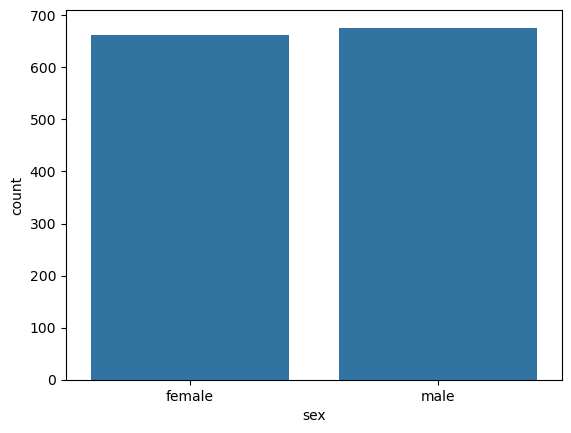

In [10]:
sns.countplot(data=df,x='sex')

<Axes: xlabel='region', ylabel='count'>

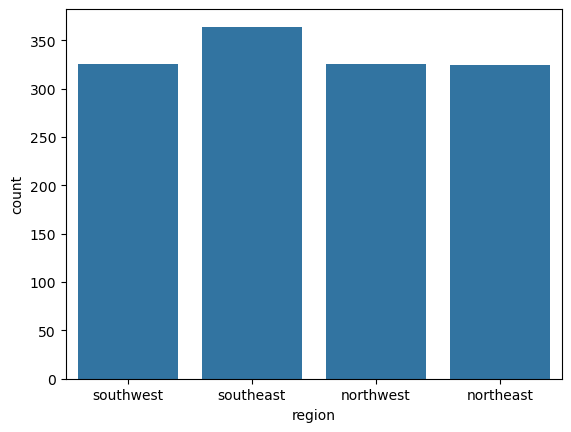

In [11]:
sns.countplot(data=df,x='region')

<Axes: xlabel='bmi', ylabel='Count'>

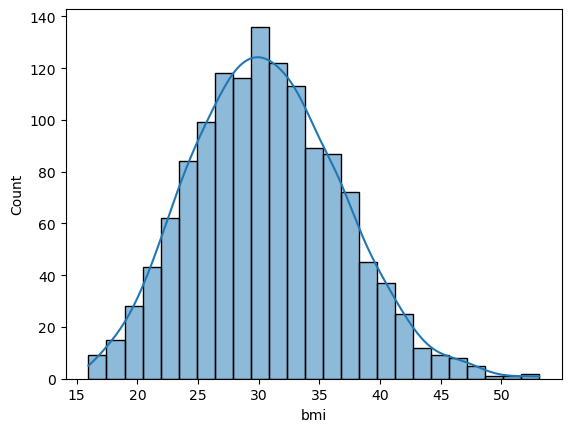

In [14]:
sns.histplot(df,x='bmi',kde=True)

<Axes: xlabel='charges', ylabel='Count'>

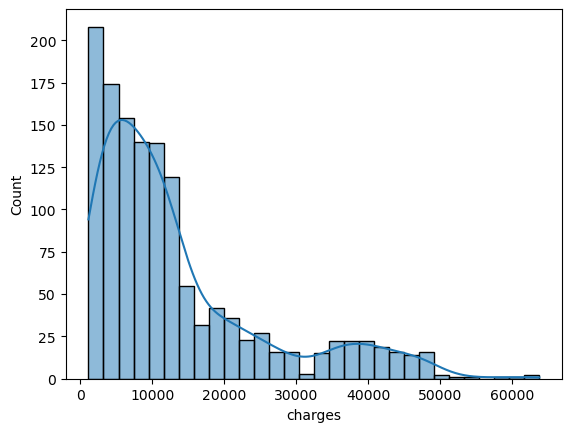

In [15]:
sns.histplot(df,x='charges',kde=True)

<Axes: xlabel='smoker', ylabel='charges'>

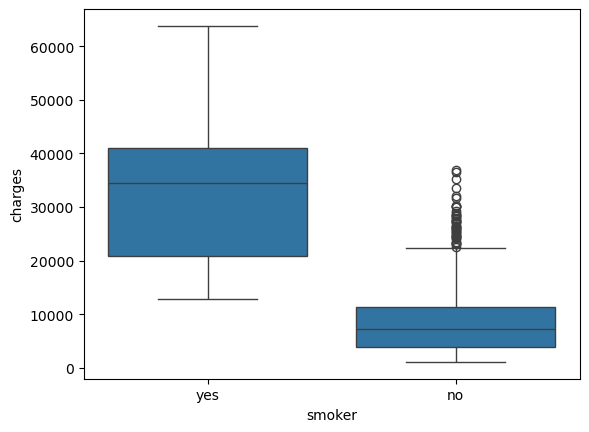

In [19]:
sns.boxplot(df,x='smoker',y='charges')

<Axes: xlabel='region', ylabel='charges'>

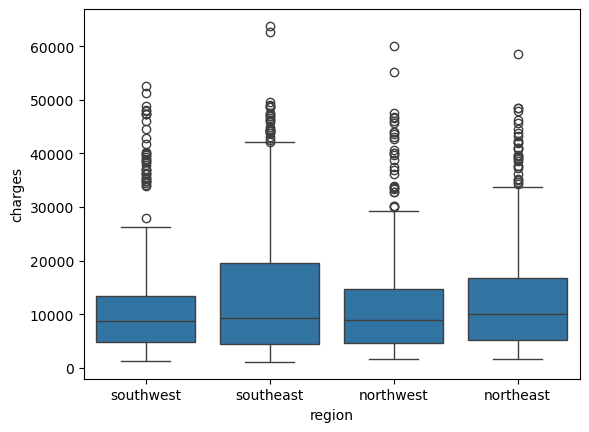

In [20]:
sns.boxplot(df,x='region',y='charges')

<Axes: xlabel='sex', ylabel='charges'>

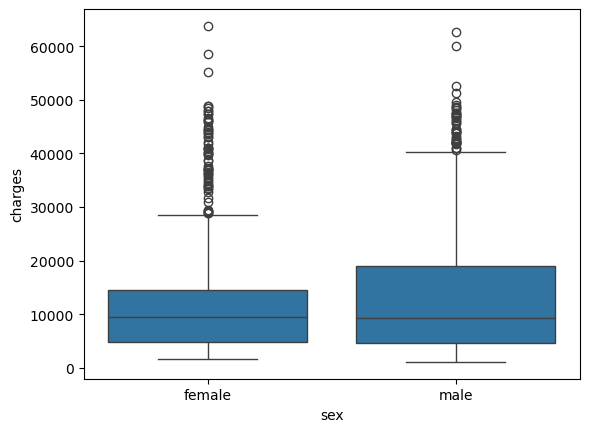

In [21]:
sns.boxplot(df,x='sex',y='charges')

<Axes: >

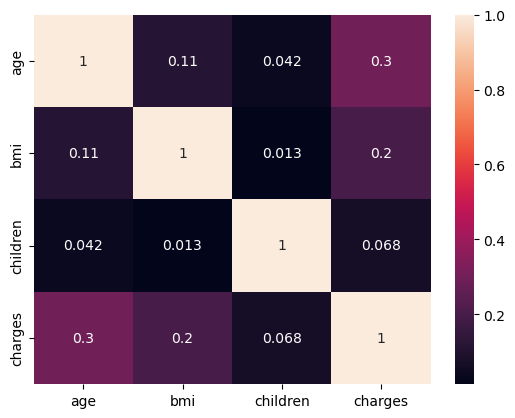

In [22]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [24]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
x=df.drop('charges',axis=1)

In [29]:
y=df[['charges']]

In [31]:
x

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [32]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [40]:
x=pd.get_dummies(x,drop_first=True)

In [41]:
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [42]:
from sklearn.model_selection import train_test_split


In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [44]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)

(1069, 8)
(268, 8)
(1069, 1)
(268, 8)


In [48]:
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(x_train,y_train)
print(model.coef_)
print(model.intercept_)
y_pred=model.predict(x_test)

[[  248.21072022   318.70144095   533.0099888   -101.54205399
  23077.76459287  -391.76145478  -838.91961573  -659.13975155]]
[-11092.65229595]


In [50]:
y_pred

array([[ 8.14369388e+03],
       [ 5.73711568e+03],
       [ 1.43693149e+04],
       [ 3.17455136e+04],
       [ 8.96238666e+03],
       [ 1.31497224e+04],
       [ 3.04467607e+04],
       [ 1.45328881e+03],
       [ 1.06330184e+04],
       [ 1.13189438e+04],
       [ 1.03778536e+04],
       [ 3.31184377e+04],
       [ 3.10772527e+04],
       [ 1.74119253e+04],
       [ 1.08016743e+04],
       [ 9.52889964e+03],
       [ 4.16103784e+03],
       [ 3.17315373e+04],
       [ 3.21938875e+03],
       [ 5.22992460e+03],
       [ 3.54979004e+03],
       [ 3.02837740e+04],
       [ 1.48989509e+04],
       [ 3.04569093e+04],
       [ 3.11077668e+04],
       [ 5.51196081e+03],
       [ 3.55030401e+04],
       [ 3.65704810e+04],
       [ 1.14123133e+04],
       [ 1.42056990e+04],
       [ 6.50234029e+03],
       [ 1.27246945e+04],
       [ 3.99806590e+02],
       [ 1.20883980e+04],
       [ 3.96592069e+04],
       [ 1.23395540e+04],
       [ 4.74412279e+03],
       [ 3.91903157e+03],
       [ 3.0

ValueError: x and y must be the same size

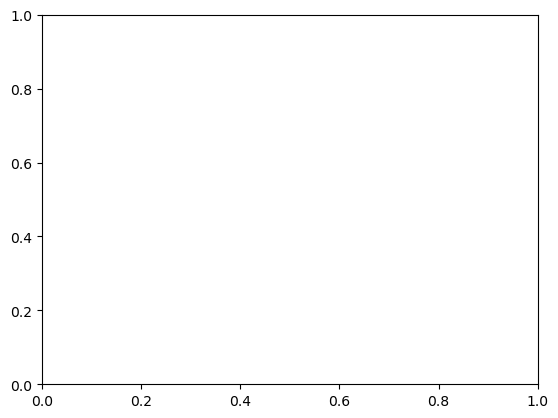

In [51]:
# import matplotlib.pyplot as plt 
# plt.scatter(x=x,y=y_test)

TypeError: plot() got an unexpected keyword argument 'x'

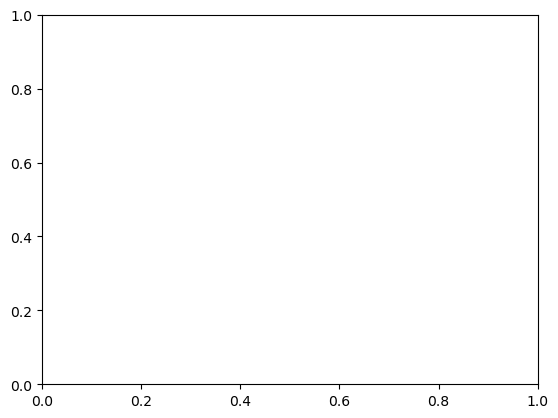

In [52]:
# plt.plot(x=x_test,y=y_pred)

In [5]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [15]:

df=pd.read_csv('fish.csv')


In [7]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [8]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: >

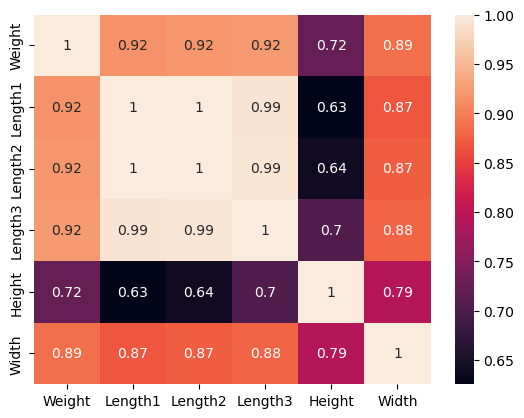

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Weight'>

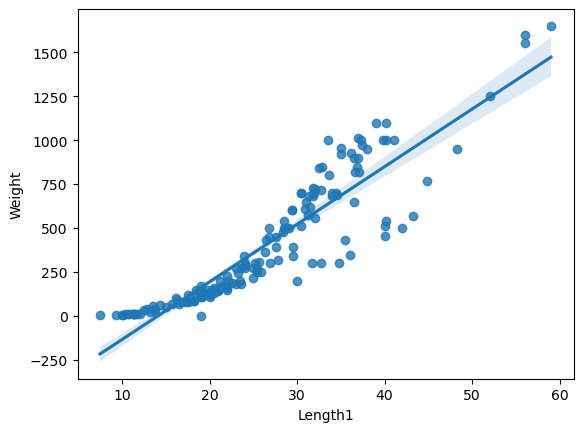

In [19]:
sns.regplot(data=df,x='Length1',y='Weight')

In [20]:
x=df[['Length1']]
y=df[['Weight']]

In [22]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
      Weight
 0     242.0
 1     290.0
 2     340.0
 3     363.0
 4     430.0
 ..      ...
 154    12.2
 155    13.4
 156    12.2
 157    19.7
 158    19.9
 
 [159 rows x 1 columns])

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print(x_test)
print(x_train)
print(y_test)
print(y_train)

     Length1  Length2  Length3   Height   Width
78      16.8     18.7     19.4   5.1992  3.1234
155     11.7     12.4     13.5   2.4300  1.2690
128     30.0     32.3     34.8   5.5680  3.3756
55      23.6     26.0     28.7   8.3804  4.2476
94      21.0     23.0     24.5   5.2185  3.6260
29      33.5     37.0     42.6  18.9570  6.6030
147     10.1     10.6     11.6   1.7284  1.1484
51      23.6     25.2     27.9   7.0866  3.9060
98      22.6     24.6     26.2   6.7334  4.1658
141     52.0     56.0     59.7  10.6863  6.9849
19      31.0     33.5     38.7  14.4738  5.7276
60      37.3     40.0     43.5  12.3540  6.5250
15      29.4     32.0     37.2  15.4380  5.5800
65      18.4     20.0     22.4   8.8928  3.2928
24      31.9     35.0     40.5  16.2405  5.5890
30      35.0     38.5     44.1  18.0369  6.3063
126     40.2     43.5     46.0  12.6040  8.1420
101     25.0     26.5     28.0   7.1680  4.1440
96      22.0     24.0     25.5   7.2930  3.7230
16      30.4     33.0     38.3  14.8604 

In [21]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

In [22]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model.coef_

array([[ 43.5352649 ,   7.82179624, -25.25670105,  23.2289123 ,
         27.06649294]])

In [24]:
model.intercept_

array([-515.30565134])

In [25]:
x_train

,Length1,Length2,Length3,Height,Width
75,15.0,16.2,17.2,4.5924,2.6316
138,43.2,46.0,48.7,7.7920,4.8700
2,23.9,26.5,31.1,12.3778,4.6961
86,20.0,22.0,23.5,6.1100,3.4075
45,20.5,22.5,25.3,7.0334,3.8203
...,...,...,...,...,...
71,24.0,26.0,29.0,11.3680,4.2340
106,25.9,28.0,29.4,7.8204,4.2042
14,29.4,32.0,37.2,14.9544,5.1708
92,20.5,22.5,24.0,6.7920,3.6240


In [26]:
y_prid=model.predict(x_test)

In [27]:
y_prid

array([[  77.68563317],
       [-159.12460639],
       [ 385.1673549 ],
       [ 300.26119445],
       [ 179.41023158],
       [ 775.66726232],
       [-214.43415538],
       [ 274.90963757],
       [ 268.44510975],
       [1116.01153223],
       [ 610.12007978],
       [ 786.34393233],
       [ 585.01831604],
       [ 172.12366335],
       [ 652.8595541 ],
       [ 785.41425179],
       [ 926.40448191],
       [ 351.83433222],
       [ 256.32442006],
       [ 587.20219745],
       [-175.74829352],
       [ 619.14709502],
       [ 516.45091187],
       [ 515.98797368],
       [ 788.64695281],
       [ 909.00622172],
       [ 219.68134027],
       [ 305.35126984],
       [-237.80116525],
       [-178.93943304],
       [ 688.57820552],
       [  23.23863135]])

ValueError: x and y must be the same size

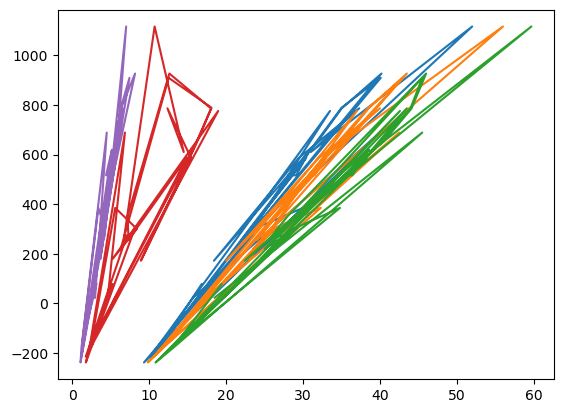

In [28]:
plt.plot(x_test,y_prid)
plt.scatter(x_test,y_test)
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_prid))
print(mean_squared_error(y_test,y_prid))
print(r2_score(y_test,y_prid))

103.90941708422301
16763.887193140756
0.8821430593048694


In [30]:
model.predict(np.array([[25]]))

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 5 features as input.

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv('fish.csv')

In [33]:
x=df.drop(['Species','Weight'],axis=1)
y=df[['Weight']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LinearRegression()
model.fit(x_test,y_test)
print(mean_absolute_error(y_test,y_prid))
print(mean_squared_error(y_test,y_prid))
print(r2_score(y_test,y_prid))


510.752636405623
392828.6280742219
-1.4348342682703565


In [34]:
x=df.drop(['Species','Weight'],axis=1)
y=df[["Weight"]]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))



ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

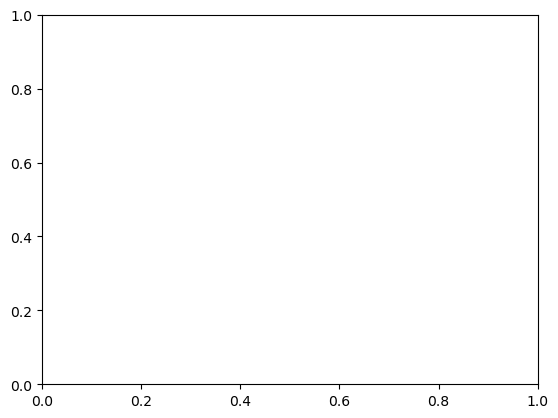

In [35]:
x=df.drop(['Species','Weight'],axis=1)
y=df[["Weight"]]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=40)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    plt.plot(test,mse)

In [ ]:
plt.show()